## Unsupervised Classification!

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sampleData = pd.read_csv("news_AP.csv")

In [9]:
# checking the different topics
print(set(sampleData["topic"]))

{'Animals', 'Transportation', 'Sports - Football', 'Healthcare'}


## Vectorize using TF-IDF and distributed embedding techniques

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

### Process the Text for TF-IDF

In [11]:
# tokenize the titles of each article
title_col = sampleData["title"]
title_tokenized = []
for title in title_col:
    tokenizer = CountVectorizer().build_tokenizer()
    title_tokenized.append(tokenizer(title))
    
print(len(title_tokenized))
print(title_tokenized)


199
[['Terminally', 'ill', 'Connecticut', 'woman', 'ends', 'her', 'life', 'on', 'her', 'own', 'terms', 'in', 'Vermont'], ['King', 'Charles', 'III', 'will', 'have', 'prostate', 'operation', 'next', 'week', 'while', 'Kate', 'recovers', 'from', 'abdominal', 'surgery'], ['Community', 'health', 'centers', 'serve', 'in', '11', 'Americans', 'They', 're', 'safety', 'net', 'under', 'stress'], ['Washington', 'state', 'reaches', 'nearly', '150', 'million', 'settlement', 'with', 'Johnson', 'Johnson', 'over', 'opioid', 'crisis'], ['Community', 'health', 'centers', 'serve', 'in', '11', 'Americans', 'They', 're', 'safety', 'net', 'under', 'stress'], ['Defense', 'Secretary', 'Lloyd', 'Austin', 'returns', 'to', 'work', 'at', 'the', 'Pentagon', 'after', 'cancer', 'surgery', 'complications'], ['Maker', 'of', 'recalled', 'sleep', 'apnea', 'machines', 'agrees', 'to', 'halt', 'sales', 'in', 'US'], ['NOT', 'REAL', 'NEWS', 'look', 'at', 'what', 'didn', 'happen', 'this', 'week'], ['Austin', 'kept', 'prostate',

In [12]:
# stemming the text
# initialize stemmer
stemmer = SnowballStemmer("english")

# apply stemming for title
stemmed_tokens_t = [] # empty list to store stemmed tokens

for title in title_tokenized:
    stem_single_title = []
    for token in title:
        stemmed = stemmer.stem(token)
        stem_single_title.append(stemmed)
    stemmed_tokens_t.append(stem_single_title)

In [14]:
# stopword removal

# get English stopwords
stop_words = set(stopwords.words('english'))

# remove stop words for title
filtered_tokens_t = [] # empty list to store stemmed tokens
for title in stemmed_tokens_t:
    temp_list = []
    # "token", in this case, would be the individual words of the title
    for token in title:
        if token not in stop_words:
            temp_list.append(token)
    filtered_tokens_t.append(temp_list)

In [15]:
# create DTM with tf-idf weighting scheme

# helps to capture word frequency of all documents

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# join tokens back into string for DTM and tf-idf

# list comprehension to join the indivdual tokens of each article title
joined_title = [' '.join(token) for token in filtered_tokens_t]

# DTM's rows are the documents and the columns are the unique words

# build the DTM with tf-idf
vectorizer = TfidfVectorizer()
dtm_tfidf = vectorizer.fit_transform(joined_title)
dtm_tfidf

<199x907 sparse matrix of type '<class 'numpy.float64'>'
	with 2017 stored elements in Compressed Sparse Row format>

### Document Embedding

In [16]:
#pip install sentence_transformers

In [17]:
from sentence_transformers import SentenceTransformer

# load pre-trained transformer model that captures semantic meanings of words, instead of frequency
model = SentenceTransformer("all-MiniLM-L6-v2")

# loading the documents into a list
# could have used .tolist() instead
documents = []
for title in sampleData["title"]:
    documents.append(title)

# compute document embeddings
doc_embeddings = model.encode(documents)

## Analyze language patterns and compare topics

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

# ground truth label
truth = [0] * 28 + [1] * 81 + [2] * 48 + [3] * 42

tfidf_kmeans = KMeans(n_clusters=4, n_init=25, random_state=7).fit(dtm_tfidf)
print(tfidf_kmeans.labels_)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[2 2 3 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 0 0 2
 0 2 2 2 0 0 2 2 0 0 0 0 0 2 2 0 0 2 2 2 0 0 0 0 2 2 2 2 2 0 2 0 2 0 2 2 2
 2 2 2 2 2 2 0 0 0 0 0 0 2 2 0 0 0 0 2 0 2 2 2 0 0 0 2 2 2 0 2 0 2 0 2 1 3
 2 1 2 2 2 2 2 2 1 2 3 2 2 2 1 3 1 2 2 2 2 2 2 2 2 2 2 3 1 3 2 1 2 2 2 2 3
 1 1 2 2 1 2 3 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 2 2 3 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [20]:
embedded_kmeans = KMeans(n_clusters=4, n_init=25, random_state=7).fit(doc_embeddings)
print(embedded_kmeans.labels_)
len(embedded_kmeans.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 3 3
 3 3 0 3 3 3 3 3 3 0 3 3 3 3 3 3 3 3 3 3 3 3 0 3 3 3 3 3 3 3 3 3 3 0 3 3 3
 3 3 3 3 3 3 3 3 3 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 1]


199

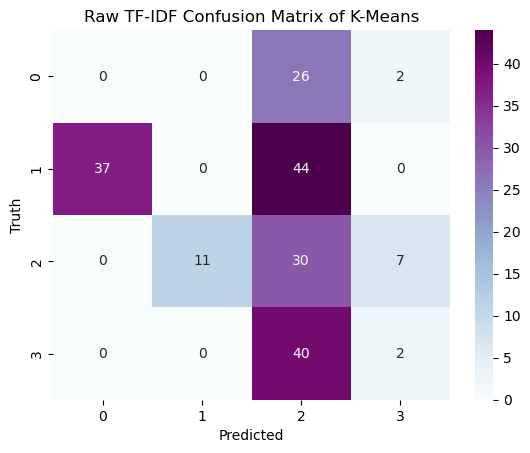

In [23]:
# preliminary confusion matrix
tfidf_cm = confusion_matrix(truth, tfidf_kmeans.labels_)
sns.heatmap(tfidf_cm, annot = True, cmap = "BuPu")
plt.title("Raw TF-IDF Confusion Matrix of K-Means")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

### Finding the corresponding true labels from arbitrary labels:

- 0 is topic 3(2)
- 1 is topic 2(1)
- 2 is topic 4(3)
- 3 is topic 1(0)

- 0 is 0
- 1 is 2
- 2 is 3
- 3 is 1

- 0 is 3
- 1 is 0
- 2 is 2
- 3 is 1

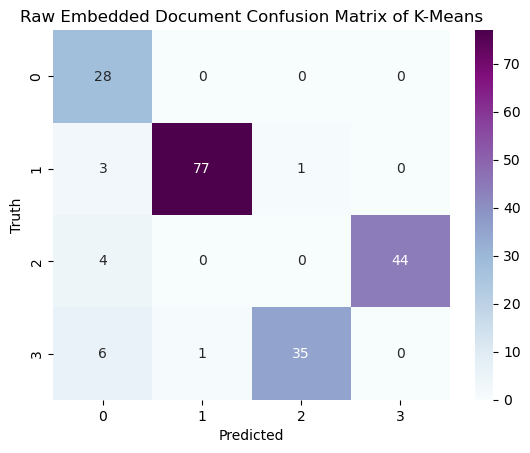

In [24]:
# preliminary confusion matrix
embedded_cm = confusion_matrix(truth, embedded_kmeans.labels_)
sns.heatmap(embedded_cm, annot = True, cmap = "BuPu")
plt.title("Raw Embedded Document Confusion Matrix of K-Means")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

### Finding which cluster fits which topic:
- 0 is topic 4(3)
- 1 is topic 2(1)
- 2 is topic 3(2)
- 3 is topic 1(0)

In [25]:
# the indices of the list are the cluster labels (0, 1, 2, 3)
# the values inside np.choose are what I want to change it to
tfidf_relabel = np.choose(tfidf_kmeans.labels_ ,[2, 1, 3, 0]).astype(np.int64)
tfidf_relabel

array([3, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 3, 2, 3, 3, 3, 2, 2, 3,
       3, 2, 2, 2, 2, 2, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 3,
       2, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3,
       2, 2, 2, 2, 3, 2, 3, 3, 3, 2, 2, 2, 3, 3, 3, 2, 3, 2, 3, 2, 3, 1,
       0, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 0, 3, 3, 3, 1, 0, 1, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 0, 1, 0, 3, 1, 3, 3, 3, 3, 0, 1, 1, 3, 3, 1, 3,
       0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3])

In [26]:
# the indices of the list are the cluster labels
# the values inside np.choose are what I want to change it to
embedded_relabel = np.choose(embedded_kmeans.labels_ ,[3, 1, 2, 0]).astype(np.int64)
embedded_relabel

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2,
       1])

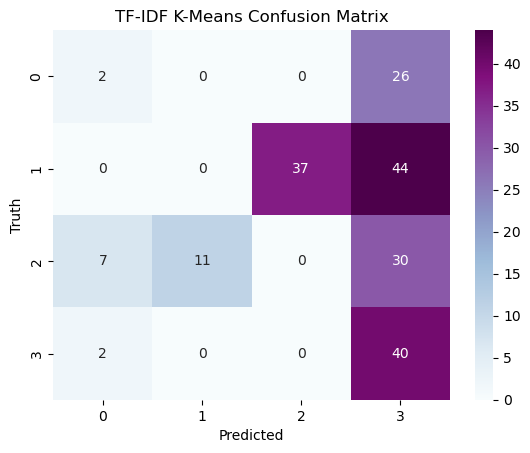

In [27]:
new_tfidf_cm = confusion_matrix(truth, tfidf_relabel)
sns.heatmap(new_tfidf_cm, annot = True, cmap = "BuPu")
plt.title("TF-IDF K-Means Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

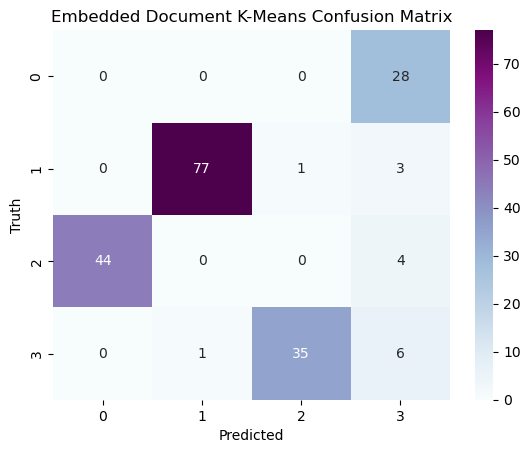

In [28]:
new_embedded_cm = confusion_matrix(truth, embedded_relabel)
sns.heatmap(new_embedded_cm, annot = True, cmap = "BuPu")
plt.title("Embedded Document K-Means Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_true = truth, y_pred = tfidf_relabel))

              precision    recall  f1-score   support

           0       0.18      0.07      0.10        28
           1       0.00      0.00      0.00        81
           2       0.00      0.00      0.00        48
           3       0.29      0.95      0.44        42

    accuracy                           0.21       199
   macro avg       0.12      0.26      0.14       199
weighted avg       0.09      0.21      0.11       199



In [30]:
print(classification_report(y_true = truth, y_pred = embedded_relabel))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.99      0.95      0.97        81
           2       0.00      0.00      0.00        48
           3       0.15      0.14      0.14        42

    accuracy                           0.42       199
   macro avg       0.28      0.27      0.28       199
weighted avg       0.43      0.42      0.42       199



**By analyzing the precision, recall, f1-scores of each topic, along with the accuracy score of each method, we can see that the embedding method was far more accurate, in terms of the model accuracy, when compared to the K-means model done from the TF-IDF sparse vectors. While the precision, recall, f1-score, and accuracy were all above 0.90 or 90% performance for the embedded document method, we observe that the same metrics for the TF-IDF method was far worse. When analyzing the performance of the sparse vector of the TF-IDF, we see that the precision fluctuated from 0.21 up to 0.83, the recall ranged from 0.15 to 0.89, the f1-score ranged from 0.25 to 0.56, and the accuracy was only 0.43 or 43%. As a result, it is clear that the embedding techniques, grabbing the semantic meanings of the words, resulted in better representations of the numerical values of the texts and led to more accurate classifications of the documents that were observed.**

## Trying with scraped Wikipedia data!

In [ ]:
myTopics = pd.read_csv("wikipediaArticleData.csv")
myTopics

,Topics,Title,Summary,Wiki_url
0,Basketball,Basketball,"Basketball is a team sport in which two teams,...",https://en.wikipedia.org/wiki/Basketball
1,Basketball,College basketball,College basketball is basketball that is playe...,https://en.wikipedia.org/wiki/College_basketball
2,Basketball,National Basketball Association,The National Basketball Association (NBA) is a...,https://en.wikipedia.org/wiki/National_Basketb...
3,Basketball,History of basketball,Basketball began with its invention in 1891 in...,https://en.wikipedia.org/wiki/History_of_baske...
4,Basketball,Basketball positions,"In basketball, there are five players on the c...",https://en.wikipedia.org/wiki/Basketball_posit...
...,...,...,...,...
195,Economy,Knowledge economy,"The knowledge economy, or knowledge-based econ...",https://en.wikipedia.org/wiki/Knowledge_economy
196,Economy,Economy of Sweden,The economy of Sweden is a highly developed ex...,https://en.wikipedia.org/wiki/Economy_of_Sweden
197,Economy,Economy of Bangladesh,The economy of Bangladesh is a major developin...,https://en.wikipedia.org/wiki/Economy_of_Bangl...
198,Economy,Economy of Egypt,"The economy of Egypt is a developing, mixed ec...",https://en.wikipedia.org/wiki/Economy_of_Egypt


**Analyze the TF-IDF of my article titles**

In [36]:
# tokenize the titles of each article
my_title_col = myTopics["Title"]
my_title_tokenized = []
for title in my_title_col:
    tokenizer = CountVectorizer().build_tokenizer()
    my_title_tokenized.append(tokenizer(title))
    
print(len(my_title_tokenized))
print(my_title_tokenized)

200
[['Basketball'], ['College', 'basketball'], ['National', 'Basketball', 'Association'], ['History', 'of', 'basketball'], ['Basketball', 'positions'], ['The', 'Basketball', 'Diaries', 'film'], ['Small', 'forward'], ['Basketball', 'Wives'], ['Anthony', 'Edwards', 'basketball'], ['Craig', 'Robinson', 'basketball'], ['Love', 'Basketball'], ['1992', 'United', 'States', 'men', 'Olympic', 'basketball', 'team'], ['Naismith', 'Memorial', 'Basketball', 'Hall', 'of', 'Fame'], ['Kuroko', 'Basketball'], ['FIBA'], ['Women', 'basketball'], ['UConn', 'Huskies', 'women', 'basketball'], ['List', 'of', 'NCAA', 'Division', 'men', 'basketball', 'champions'], ['FIBA', 'Basketball', 'World', 'Cup'], ['National', 'Basketball', 'League'], ['Rules', 'of', 'basketball'], ['List', 'of', 'nicknames', 'in', 'basketball'], ['American', 'Basketball', 'Association'], ['List', 'of', 'basketball', 'leagues'], ['Duke', 'Blue', 'Devils', 'men', 'basketball'], ['List', 'of', 'All', 'Atlantic', 'Coast', 'Conference', 'me

In [37]:
# stemming the text
# initialize stemmer
my_stemmer = SnowballStemmer("english")

# apply stemming for title
my_stemmed_tokens_t = [] # empty list to store stemmed tokens

for title in my_title_tokenized:
    my_stem_single_title = []
    for token in title:
        stemmed = my_stemmer.stem(token)
        my_stem_single_title.append(stemmed)
    my_stemmed_tokens_t.append(my_stem_single_title)

In [38]:
# stopword removal

# get English stopwords
stop_words = set(stopwords.words('english'))

# remove stop words for title
my_filtered_tokens_t = [] # empty list to store stemmed tokens
for title in my_stemmed_tokens_t:
    my_temp_list = []
    # "token", in this case, would be the individual words of the title
    for token in title:
        if token not in stop_words:
            my_temp_list.append(token)
    my_filtered_tokens_t.append(my_temp_list)

In [39]:
# create DTM with tf-idf weighting scheme

# helps to capture word frequency of all documents

# join tokens back into string for DTM and tf-idf

# list comprehension to join the indivdual tokens of each article title
my_joined_title = [' '.join(token) for token in my_filtered_tokens_t]

# DTM's rows are the documents and the columns are the unique words

# build the DTM with tf-idf
my_vectorizer = TfidfVectorizer()
my_dtm_tfidf = my_vectorizer.fit_transform(my_joined_title)
my_dtm_tfidf

<200x235 sparse matrix of type '<class 'numpy.float64'>'
	with 478 stored elements in Compressed Sparse Row format>

**Applying Document Embedding Technique**

In [40]:
from sentence_transformers import SentenceTransformer

# load pre-trained transformer model that captures semantic meanings of words, instead of frequency
my_model = SentenceTransformer("all-MiniLM-L6-v2")

# loading the documents into a list
my_documents = []
for title in myTopics["Title"]:
    my_documents.append(title)

# compute document embeddings
my_doc_embeddings = my_model.encode(my_documents)

**Apply K-Means Clustering**

In [41]:
# ground truth label
my_truth = [0] * 50 + [1] * 50 + [2] * 50 + [3] * 50

my_tfidf_kmeans = KMeans(n_clusters=4, n_init=25, random_state=7).fit(my_dtm_tfidf)
print(my_tfidf_kmeans.labels_)


[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 3 1 1 1 1 3 3 1 1 1 1 1 3 3 3 1 3 1 1 3 1 0 0 0 0 3 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3]


In [42]:
my_embedded_kmeans = KMeans(n_clusters=4, n_init=25, random_state=7).fit(my_doc_embeddings)
print(my_embedded_kmeans.labels_)
len(my_embedded_kmeans.labels_)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 3 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


200

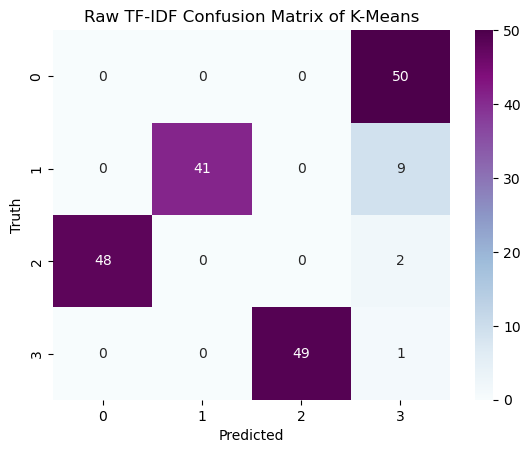

In [43]:
my_tfidf_cm = confusion_matrix(my_truth, my_tfidf_kmeans.labels_)
sns.heatmap(my_tfidf_cm, annot = True, cmap = "BuPu")
plt.title("Raw TF-IDF Confusion Matrix of K-Means")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

### Finding which cluster fits which topic:

- 0 is 1
- 1 is 3
- 2 is 2
- 3 is 0

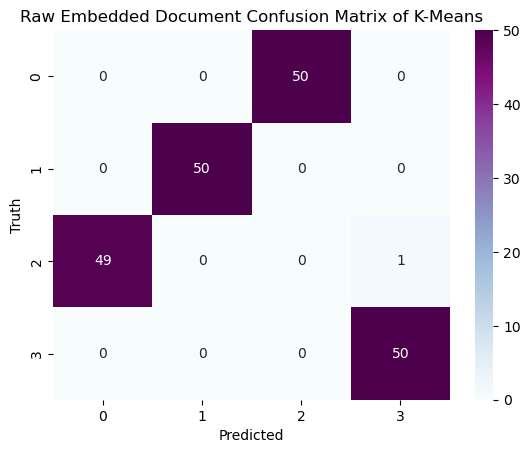

In [44]:
my_embedded_cm = confusion_matrix(my_truth, my_embedded_kmeans.labels_)
sns.heatmap(my_embedded_cm, annot = True, cmap = "BuPu")
plt.title("Raw Embedded Document Confusion Matrix of K-Means")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

### Find which cluster fits which topic:

- 0 is 2
- 1 is 1
- 2 is 0
- 3 is 3

In [45]:
# the indices of the list are the cluster labels
# the values inside np.choose are what I want to change it to
my_tfidf_relabel = np.choose(my_tfidf_kmeans.labels_ ,[1, 3, 2, 0]).astype(np.int64)
my_tfidf_relabel

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 0, 0, 3, 3,
       3, 3, 3, 0, 0, 0, 3, 0, 3, 3, 0, 3, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0])

In [46]:
# the indices of the list are the cluster labels
# the values inside np.choose are what I want to change it to
my_embedded_relabel = np.choose(my_embedded_kmeans.labels_ ,[2, 1, 0, 3]).astype(np.int64)
my_embedded_relabel

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3])

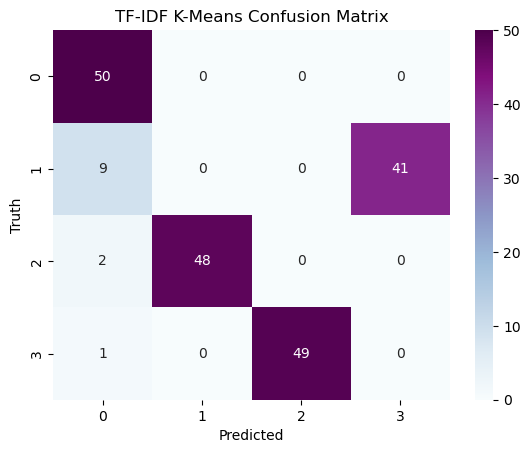

In [47]:
my_new_tfidf_cm = confusion_matrix(my_truth, my_tfidf_relabel)
sns.heatmap(my_new_tfidf_cm, annot = True, cmap = "BuPu")
plt.title("TF-IDF K-Means Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

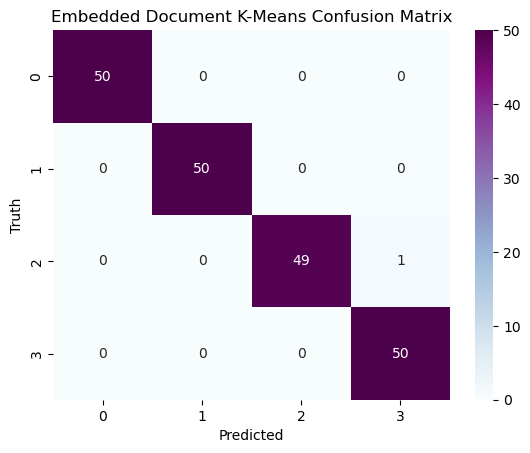

In [48]:
my_new_embedded_cm = confusion_matrix(my_truth, my_embedded_relabel)
sns.heatmap(my_new_embedded_cm, annot = True, cmap = "BuPu")
plt.title("Embedded Document K-Means Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [49]:
print(classification_report(y_true = my_truth, y_pred = my_tfidf_relabel))

              precision    recall  f1-score   support

           0       0.81      1.00      0.89        50
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00        50
           3       0.00      0.00      0.00        50

    accuracy                           0.25       200
   macro avg       0.20      0.25      0.22       200
weighted avg       0.20      0.25      0.22       200



In [50]:
print(classification_report(y_true = my_truth, y_pred = my_embedded_relabel))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      0.98      0.99        50
           3       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

